# Stock price prediction using simple ML techniques 

## Data Fetchig from keggel

In [1]:
! pip install numpy pandas matplotlib scikit-learn pandas_ta

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_ta as ta

In [3]:
raw_data = pd.read_csv('NVDA.csv')
raw_data.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-22,0.037615,0.041016,0.048828,0.038802,0.043750,2714688000
1,1999-01-25,0.041556,0.045313,0.045833,0.041016,0.044271,510480000
2,1999-01-26,0.038331,0.041797,0.046745,0.041146,0.045833,343200000
3,1999-01-27,0.038212,0.041667,0.042969,0.039583,0.041927,244368000
4,1999-01-28,0.038092,0.041536,0.041927,0.041276,0.041667,227520000


### Date Range of Raw Data
Calculate the minimum and maximum values in the `Date` column to identify the span of the dataset.


In [4]:
# compute date range
raw_data['Date'] = pd.to_datetime(raw_data['Date'])
min_date = raw_data['Date'].min()
max_date = raw_data['Date'].max()
print("Date range:", min_date.date(), "to", max_date.date())


Date range: 1999-01-22 to 2025-02-14


### Simple Technical Indicator
We'll compute a 20‑day simple moving average (SMA) using `pandas_ta` and plot it alongside the closing price.

In [8]:
import pandas as pd
import pandas_ta as ta

# Ensure numeric data types
raw_data['Close'] = raw_data['Close'].astype(float)
raw_data['High'] = raw_data['High'].astype(float)
raw_data['Low'] = raw_data['Low'].astype(float)
raw_data['Volume'] = raw_data['Volume'].astype(float)

# 1. Simple Moving Average (SMA)
raw_data['SMA_20'] = ta.sma(raw_data['Close'], length=20)
raw_data['SMA_50'] = ta.sma(raw_data['Close'], length=50)

# 2. Exponential Moving Average (EMA)
raw_data['EMA_12'] = ta.ema(raw_data['Close'], length=12)
raw_data['EMA_26'] = ta.ema(raw_data['Close'], length=26)

# 3. Relative Strength Index (RSI)
raw_data['RSI'] = ta.rsi(raw_data['Close'], length=14)

# 4. MACD
macd = ta.macd(raw_data['Close'], fast=12, slow=26, signal=9)
raw_data['MACD'] = macd['MACD_12_26_9']
raw_data['MACD_Signal'] = macd['MACDs_12_26_9']

# 5. Bollinger Bands
bb = ta.bbands(raw_data['Close'], length=20)
raw_data['BB_Lower'] = bb.iloc[:,0]
raw_data['BB_Mid'] = bb.iloc[:,1]
raw_data['BB_Upper'] = bb.iloc[:,2]

# 6. Average True Range (ATR)
raw_data['ATR'] = ta.atr(
    high=raw_data['High'],
    low=raw_data['Low'],
    close=raw_data['Close'],
    length=14
)

# 7. Stochastic Oscillator
stoch = ta.stoch(
    high=raw_data['High'],
    low=raw_data['Low'],
    close=raw_data['Close'],
    k=14,
    d=3
)

raw_data['Stoch_K'] = stoch['STOCHk_14_3_3']
raw_data['Stoch_D'] = stoch['STOCHd_14_3_3']

# 8. On Balance Volume
raw_data['OBV'] = ta.obv(raw_data['Close'], raw_data['Volume'])

# 9. Commodity Channel Index
raw_data['CCI'] = ta.cci(
    high=raw_data['High'],
    low=raw_data['Low'],
    close=raw_data['Close'],
    length=20
)

# 10. Rate of Change
raw_data['ROC'] = ta.roc(raw_data['Close'], length=12)

print("Indicators calculated successfully!")

print(
    raw_data[['Date','Close','SMA_20','EMA_12','RSI','MACD','ATR','OBV']].tail(10)
)

Indicators calculated successfully!
           Date       Close      SMA_20      EMA_12        RSI      MACD  \
6548 2025-02-03  116.660004  134.640001  128.495143  36.814104 -4.343442   
6549 2025-02-04  118.650002  133.349001  126.980506  38.779871 -4.807073   
6550 2025-02-05  124.830002  132.119001  126.649659  44.549380 -4.622544   
6551 2025-02-06  128.679993  131.546001  126.962018  47.846852 -4.118169   
6552 2025-02-07  129.839996  131.032501  127.404784  48.834130 -3.583537   
6553 2025-02-10  133.570007  130.915501  128.353280  51.981874 -2.826277   
6554 2025-02-11  132.800003  130.894001  129.037391  51.280517 -2.262199   
6555 2025-02-12  131.139999  130.863002  129.360869  49.722957 -1.926899   
6556 2025-02-13  135.289993  130.815501  130.273042  53.523526 -1.311187   
6557 2025-02-14  138.850006  131.079501  131.592575  56.557309 -0.529860   

           ATR           OBV  
6548  7.660247  1.575374e+11  
6549  7.437372  1.577939e+11  
6550  7.359703  1.580561e+11  
655

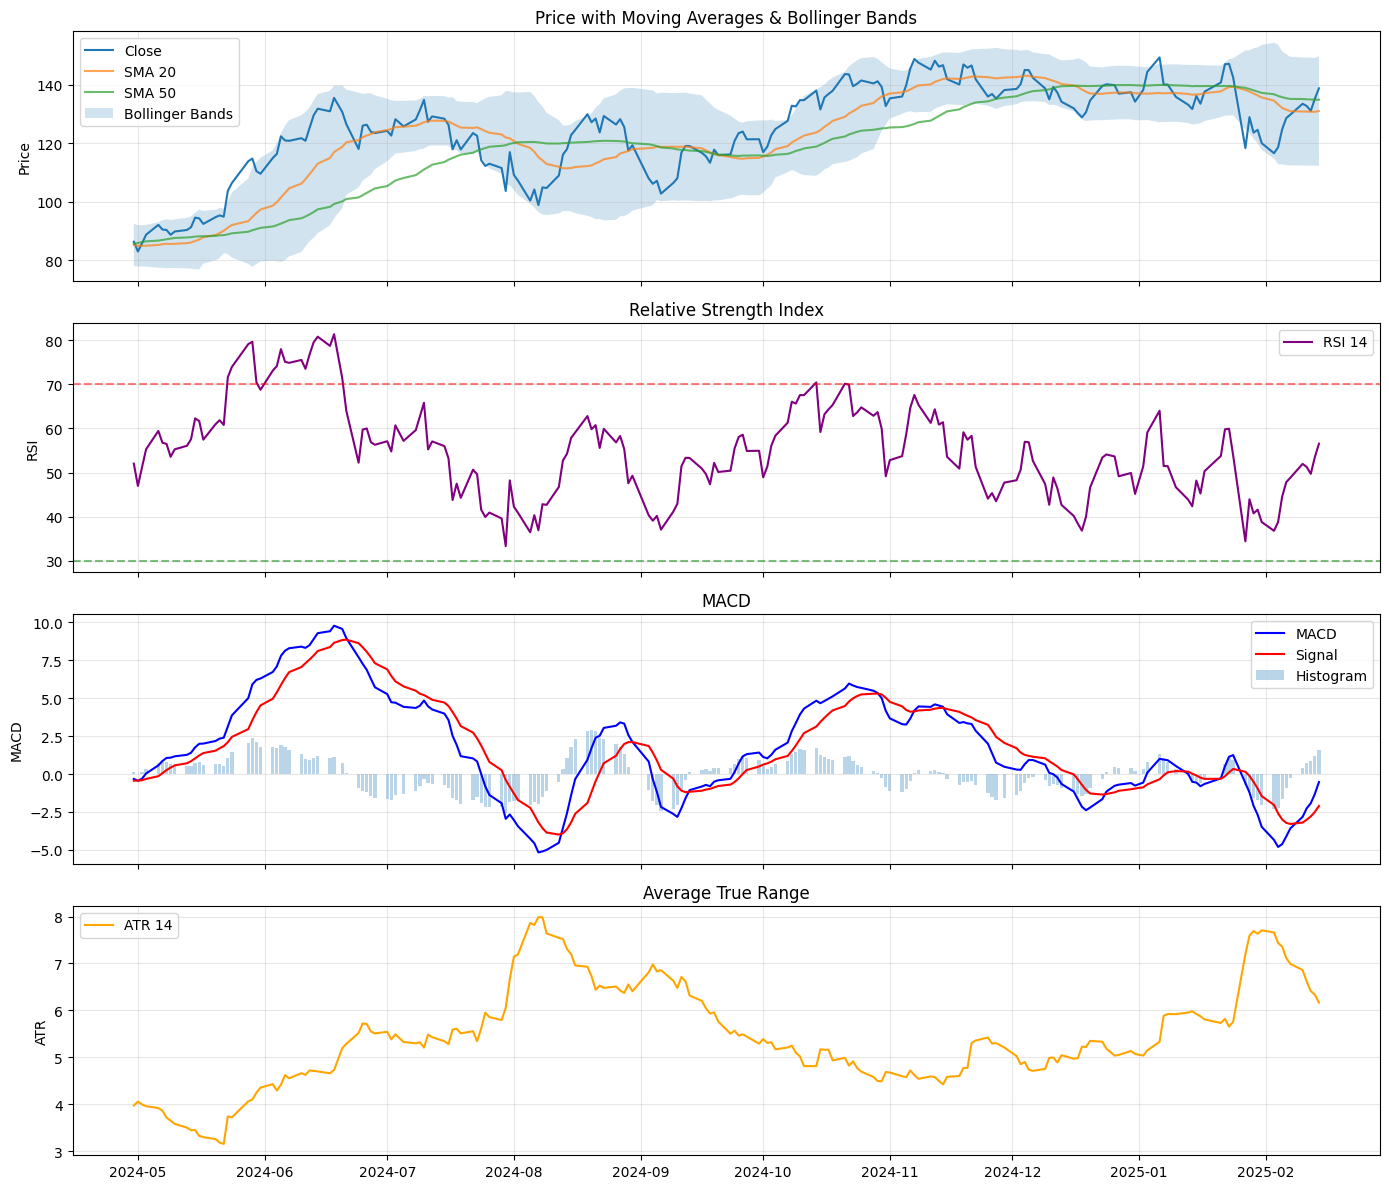

Total indicators added: 10+
Dataset shape: (6558, 23)
Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'MACD_Signal', 'BB_Lower', 'BB_Mid', 'BB_Upper', 'ATR', 'Stoch_K', 'Stoch_D', 'OBV', 'CCI', 'ROC']


In [9]:
import matplotlib.pyplot as plt

plot_data = raw_data.tail(200)  # choose period

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price with SMAs and Bollinger Bands
axes[0].plot(plot_data['Date'], plot_data['Close'], label='Close', linewidth=1.5)
axes[0].plot(plot_data['Date'], plot_data['SMA_20'], label='SMA 20', alpha=0.7)
axes[0].plot(plot_data['Date'], plot_data['SMA_50'], label='SMA 50', alpha=0.7)

axes[0].fill_between(
    plot_data['Date'],
    plot_data['BB_Upper'],
    plot_data['BB_Lower'],
    alpha=0.2,
    label='Bollinger Bands'
)

axes[0].set_ylabel('Price')
axes[0].set_title('Price with Moving Averages & Bollinger Bands')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# RSI
axes[1].plot(plot_data['Date'], plot_data['RSI'], label='RSI 14', color='purple')
axes[1].axhline(70, color='r', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='g', linestyle='--', alpha=0.5)

axes[1].set_ylabel('RSI')
axes[1].set_title('Relative Strength Index')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# MACD
axes[2].plot(plot_data['Date'], plot_data['MACD'], label='MACD', color='blue')
axes[2].plot(plot_data['Date'], plot_data['MACD_Signal'], label='Signal', color='red')

axes[2].bar(
    plot_data['Date'],
    plot_data['MACD'] - plot_data['MACD_Signal'],
    label='Histogram',
    alpha=0.3
)

axes[2].set_ylabel('MACD')
axes[2].set_title('MACD')
axes[2].legend()
axes[2].grid(True, alpha=0.3)


# ATR
axes[3].plot(plot_data['Date'], plot_data['ATR'], label='ATR 14', color='orange')

axes[3].set_ylabel('ATR')
axes[3].set_title('Average True Range')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"Total indicators added: 10+")
print(f"Dataset shape: {raw_data.shape}")
print(f"Columns: {raw_data.columns.tolist()}")

In [10]:
raw_data.to_csv("with_indicators.csv")

1) rate of change preferred
2) maybe start with a simple model and then expand
1 - positive price change; 0 - negative price change